In [1]:
import re
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns


In [2]:
df = pd.read_csv("data/jiji_housing_raw.csv")
df.head(50)

,title,property_size,bedrooms,bathrooms,furnishing,region,region_name,region_parent_name,is_boost,price
0,2bdrm Apartment in Life Camp for sale,250.0,2,2,unfurnished,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,False,"₦ 75,000,000"
1,Furnished 3bdrm Bungalow in Zone B for sale,600.0,3,4,furnished,"Apo District, Zone B",Zone B,Apo District,enterprise,"₦ 200,000,000"
2,"1bdrm Bungalow in Ughoton, Warri for sale",232.0,1,1,unfurnished,"Delta State, Warri",Warri,Delta State,vip_gold,"₦ 40,000,000"
3,3bdrm Block of Flats in Oshimili South for sale,1800.0,3,3,semi-furnished,"Delta State, Oshimili South",Oshimili South,Delta State,False,"₦ 350,000,000"
4,4bdrm Duplex in Lekki for sale,200.0,4,5,semi-furnished,"Lagos State, Lekki",Lekki,Lagos State,False,"₦ 205,000,000"
5,3bdrm Duplex in Ado / Ajah for sale,500.0,3,3,semi-furnished,"Ajah, Ado / Ajah",Ado / Ajah,Ajah,False,"₦ 125,000,000"
6,3bdrm Apartment in Ikate for sale,500.0,3,3,unfurnished,"Lekki, Ikate",Ikate,Lekki,False,"₦ 200,000,000"
7,"5bdrm Mansion in Estate, Enugu for sale",750.0,5,7,semi-furnished,"Enugu State, Enugu",Enugu,Enugu State,enterprise,"₦ 250,000,000"
8,3bdrm Duplex in Lekki Phase 1 for sale,500.0,3,3,semi-furnished,"Lekki, Lekki Phase 1",Lekki Phase 1,Lekki,False,"₦ 300,000,000"
9,4bdrm Duplex in Lekki Phase 1 for sale,500.0,4,4,unfurnished,"Lekki, Lekki Phase 1",Lekki Phase 1,Lekki,False,"₦ 650,000,000"


In [3]:
pd.set_option('display.float_format', lambda x: f"{x:.2f}")

Task 2: Data Cleaning


Objective:


1. Prepare the dataset for reliable analysis.
Questions to Guide Cleaning:
Missing Values


Which columns have missing values?


How will you handle missing property size, bedrooms, bathrooms, or furnishing?


In [4]:
df.isnull().sum()

title                 0
property_size         6
bedrooms              0
bathrooms             0
furnishing            0
region                0
region_name           0
region_parent_name    4
is_boost              0
price                 0
dtype: int64

In [5]:
df.dropna(inplace=True)
df

,title,property_size,bedrooms,bathrooms,furnishing,region,region_name,region_parent_name,is_boost,price
0,2bdrm Apartment in Life Camp for sale,250.00,2,2,unfurnished,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,False,"₦ 75,000,000"
1,Furnished 3bdrm Bungalow in Zone B for sale,600.00,3,4,furnished,"Apo District, Zone B",Zone B,Apo District,enterprise,"₦ 200,000,000"
2,"1bdrm Bungalow in Ughoton, Warri for sale",232.00,1,1,unfurnished,"Delta State, Warri",Warri,Delta State,vip_gold,"₦ 40,000,000"
3,3bdrm Block of Flats in Oshimili South for sale,1800.00,3,3,semi-furnished,"Delta State, Oshimili South",Oshimili South,Delta State,False,"₦ 350,000,000"
4,4bdrm Duplex in Lekki for sale,200.00,4,5,semi-furnished,"Lagos State, Lekki",Lekki,Lagos State,False,"₦ 205,000,000"
...,...,...,...,...,...,...,...,...,...,...
3995,Furnished 3bdrm Block of Flats in Wuye for sale,350.00,3,4,furnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,"₦ 550,000,000"
3996,5bdrm Duplex in Wuye for sale,1200.00,5,6,unfurnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,"₦ 650,000,000"
3997,4bdrm Duplex in Wuye for sale,650.00,4,5,unfurnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,"₦ 450,000,000"
3998,Furnished 7bdrm Mansion in Prices Estate Ikate...,700.00,7,7,furnished,"Lekki, Ikate",Ikate,Lekki,diamond,"₦ 1,700,000,000"


In [6]:
df.isnull().sum()

title                 0
property_size         0
bedrooms              0
bathrooms             0
furnishing            0
region                0
region_name           0
region_parent_name    0
is_boost              0
price                 0
dtype: int64

In [7]:
#How will you handle missing property size, bedrooms, bathrooms, or furnishing?
df["bedrooms"] = df["bedrooms"].fillna(0)
df["bathrooms"] = df["bathrooms"].fillna(0)
df["property_size"] = df["property_size"].fillna("Unknown")
df["furnishing"] = df["furnishing"].fillna("Unknown")

df

,title,property_size,bedrooms,bathrooms,furnishing,region,region_name,region_parent_name,is_boost,price
0,2bdrm Apartment in Life Camp for sale,250.00,2,2,unfurnished,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,False,"₦ 75,000,000"
1,Furnished 3bdrm Bungalow in Zone B for sale,600.00,3,4,furnished,"Apo District, Zone B",Zone B,Apo District,enterprise,"₦ 200,000,000"
2,"1bdrm Bungalow in Ughoton, Warri for sale",232.00,1,1,unfurnished,"Delta State, Warri",Warri,Delta State,vip_gold,"₦ 40,000,000"
3,3bdrm Block of Flats in Oshimili South for sale,1800.00,3,3,semi-furnished,"Delta State, Oshimili South",Oshimili South,Delta State,False,"₦ 350,000,000"
4,4bdrm Duplex in Lekki for sale,200.00,4,5,semi-furnished,"Lagos State, Lekki",Lekki,Lagos State,False,"₦ 205,000,000"
...,...,...,...,...,...,...,...,...,...,...
3995,Furnished 3bdrm Block of Flats in Wuye for sale,350.00,3,4,furnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,"₦ 550,000,000"
3996,5bdrm Duplex in Wuye for sale,1200.00,5,6,unfurnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,"₦ 650,000,000"
3997,4bdrm Duplex in Wuye for sale,650.00,4,5,unfurnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,"₦ 450,000,000"
3998,Furnished 7bdrm Mansion in Prices Estate Ikate...,700.00,7,7,furnished,"Lekki, Ikate",Ikate,Lekki,diamond,"₦ 1,700,000,000"


In [8]:
df['property_size'].unique()

array([ 250.,  600.,  232., 1800.,  200.,  500.,  750.,  350.,  180.,
        684.,  520.,  550.,  220.,  648.,  400., 1848.,  300.,  580.,
        450., 1100.,  202.,  640.,  420.,  624.,  850.,   10., 3000.,
        470.,  700.,  230.,  309., 2000.,  650., 1386., 2500., 1150.,
        464.,  620.,  320., 1200.,  405.,  800.,  120.,  330.,  100.,
       1350.,  630.,   50.,  572., 1000.,  269.,   80., 5000.,  715.,
        380.,  150.,  252.,  160.,  225.,  870.,  460., 2100., 2120.,
        912.,  560.,  900., 1300.,  670., 2074., 1375.,  950., 1400.,
       1533.,  635.,  240., 1434.,   55.,  540.,  453.,  780.,  680.,
        530.,   15., 2400.,  660.,  430., 1115., 1059.,  329.,  817.,
       1365.,  310.,  608.,  465.,  812.,  130.,  445.,  674.,  410.,
       1794., 1500., 1088., 4500.,  790.,  270.,  260.,  480., 2800.,
        802., 1070.,  360.,  512.,  475., 2346., 1675.,  839., 1998.,
       1625.,  125., 1735.,  510.,  629.,  502., 1750.,  501.,  575.,
        639.,   24.,

In [9]:
df['region_parent_name'].unique()

<ArrowStringArray>
[          'Gwarinpa',       'Apo District',        'Delta State',
        'Lagos State',               'Ajah',              'Lekki',
        'Enugu State',               'Ogba',           'Maryland',
              'Agege',        'Abuja (FCT)',           'Surulere',
              'Ikeja',            'Gbagada',    'Victoria Island',
              'Ogudu',              'Ikoyi',           'Alimosho',
             'Mushin',              'Ojodu',             'Magodo',
            'Ilupeju',            'Ikorodu',               'Yaba',
             'Kosofe',     'Lugbe District',      'Port-Harcourt',
       'Ifako-Ijaiye',         'Ogun State',          'Oyo State',
         'Osun State',              'Ipaja',       'Amuwo-Odofin',
    'Akwa Ibom State',             'Ibadan',            'Katampe',
              'Ibeju',        'Kwara State',       'Rivers State',
             'Egbeda',  'Cross River State',      'Ikotun/Igando',
          'Imo State',             'Ejigbo'

2. Price Cleaning


Convert the price from strings like “₦ 85,500,000” to float (85500000.00)


Are there outlier prices that should be removed?



In [10]:
df['region_parent_name'] = df['region_parent_name'].replace(
    ['Ajah', 'Ibeju', 'Lagos State', 'Ikorodu', 'Magodo', 'Lekki', 'Ikeja', 'Gbagada', 
    'Ikotun/Igando', 'Lugbe District',  
    'Surulere','Isolo', 'Ojodu', 
    'Egbeda', 'Ogudu','Maryland', 
     'Kosofe', 'Alimosho', 'Ikoyi', 
     'Egbe/Idimu','Agege', 'Victoria Island', 
     'Ipaja', 'Amuwo-Odofin', 'Ogba', 'Sagamu', 'Lagos Island (Eko)', 
     'Oshodi', 'Mushin', 'Shomolu', 'Ifako-Ijaiye', 'Epe'], 
     'Lagos State'
)
df

,title,property_size,bedrooms,bathrooms,furnishing,region,region_name,region_parent_name,is_boost,price
0,2bdrm Apartment in Life Camp for sale,250.00,2,2,unfurnished,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,False,"₦ 75,000,000"
1,Furnished 3bdrm Bungalow in Zone B for sale,600.00,3,4,furnished,"Apo District, Zone B",Zone B,Apo District,enterprise,"₦ 200,000,000"
2,"1bdrm Bungalow in Ughoton, Warri for sale",232.00,1,1,unfurnished,"Delta State, Warri",Warri,Delta State,vip_gold,"₦ 40,000,000"
3,3bdrm Block of Flats in Oshimili South for sale,1800.00,3,3,semi-furnished,"Delta State, Oshimili South",Oshimili South,Delta State,False,"₦ 350,000,000"
4,4bdrm Duplex in Lekki for sale,200.00,4,5,semi-furnished,"Lagos State, Lekki",Lekki,Lagos State,False,"₦ 205,000,000"
...,...,...,...,...,...,...,...,...,...,...
3995,Furnished 3bdrm Block of Flats in Wuye for sale,350.00,3,4,furnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,"₦ 550,000,000"
3996,5bdrm Duplex in Wuye for sale,1200.00,5,6,unfurnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,"₦ 650,000,000"
3997,4bdrm Duplex in Wuye for sale,650.00,4,5,unfurnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,"₦ 450,000,000"
3998,Furnished 7bdrm Mansion in Prices Estate Ikate...,700.00,7,7,furnished,"Lekki, Ikate",Ikate,Lagos State,diamond,"₦ 1,700,000,000"


In [11]:
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("₦", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

df

,title,property_size,bedrooms,bathrooms,furnishing,region,region_name,region_parent_name,is_boost,price
0,2bdrm Apartment in Life Camp for sale,250.00,2,2,unfurnished,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,False,75000000
1,Furnished 3bdrm Bungalow in Zone B for sale,600.00,3,4,furnished,"Apo District, Zone B",Zone B,Apo District,enterprise,200000000
2,"1bdrm Bungalow in Ughoton, Warri for sale",232.00,1,1,unfurnished,"Delta State, Warri",Warri,Delta State,vip_gold,40000000
3,3bdrm Block of Flats in Oshimili South for sale,1800.00,3,3,semi-furnished,"Delta State, Oshimili South",Oshimili South,Delta State,False,350000000
4,4bdrm Duplex in Lekki for sale,200.00,4,5,semi-furnished,"Lagos State, Lekki",Lekki,Lagos State,False,205000000
...,...,...,...,...,...,...,...,...,...,...
3995,Furnished 3bdrm Block of Flats in Wuye for sale,350.00,3,4,furnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,550000000
3996,5bdrm Duplex in Wuye for sale,1200.00,5,6,unfurnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,650000000
3997,4bdrm Duplex in Wuye for sale,650.00,4,5,unfurnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,450000000
3998,Furnished 7bdrm Mansion in Prices Estate Ikate...,700.00,7,7,furnished,"Lekki, Ikate",Ikate,Lagos State,diamond,1700000000


In [12]:
df["bedrooms"] = pd.to_numeric(df["bedrooms"], errors="coerce")
df["bathrooms"] = pd.to_numeric(df["bathrooms"], errors="coerce")
df

,title,property_size,bedrooms,bathrooms,furnishing,region,region_name,region_parent_name,is_boost,price
0,2bdrm Apartment in Life Camp for sale,250.00,2,2,unfurnished,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,False,75000000
1,Furnished 3bdrm Bungalow in Zone B for sale,600.00,3,4,furnished,"Apo District, Zone B",Zone B,Apo District,enterprise,200000000
2,"1bdrm Bungalow in Ughoton, Warri for sale",232.00,1,1,unfurnished,"Delta State, Warri",Warri,Delta State,vip_gold,40000000
3,3bdrm Block of Flats in Oshimili South for sale,1800.00,3,3,semi-furnished,"Delta State, Oshimili South",Oshimili South,Delta State,False,350000000
4,4bdrm Duplex in Lekki for sale,200.00,4,5,semi-furnished,"Lagos State, Lekki",Lekki,Lagos State,False,205000000
...,...,...,...,...,...,...,...,...,...,...
3995,Furnished 3bdrm Block of Flats in Wuye for sale,350.00,3,4,furnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,550000000
3996,5bdrm Duplex in Wuye for sale,1200.00,5,6,unfurnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,650000000
3997,4bdrm Duplex in Wuye for sale,650.00,4,5,unfurnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,450000000
3998,Furnished 7bdrm Mansion in Prices Estate Ikate...,700.00,7,7,furnished,"Lekki, Ikate",Ikate,Lagos State,diamond,1700000000


In [13]:
#exclude an outliers in dataframe

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
Q1
Q3
IQR = Q3 -Q1
IQR

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ( df['price'] < lower_bound) | ( df['price'] > upper_bound)

print(outliers.sum())

new_df = df[
    (df['price'] > lower_bound) & ( df['price'] < upper_bound)
] 

new_df

355


,title,property_size,bedrooms,bathrooms,furnishing,region,region_name,region_parent_name,is_boost,price
0,2bdrm Apartment in Life Camp for sale,250.00,2,2,unfurnished,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,False,75000000
1,Furnished 3bdrm Bungalow in Zone B for sale,600.00,3,4,furnished,"Apo District, Zone B",Zone B,Apo District,enterprise,200000000
2,"1bdrm Bungalow in Ughoton, Warri for sale",232.00,1,1,unfurnished,"Delta State, Warri",Warri,Delta State,vip_gold,40000000
3,3bdrm Block of Flats in Oshimili South for sale,1800.00,3,3,semi-furnished,"Delta State, Oshimili South",Oshimili South,Delta State,False,350000000
4,4bdrm Duplex in Lekki for sale,200.00,4,5,semi-furnished,"Lagos State, Lekki",Lekki,Lagos State,False,205000000
...,...,...,...,...,...,...,...,...,...,...
3994,5bdrm Duplex in Mjguzape for sale,500.00,5,7,unfurnished,"Abuja (FCT), Guzape District",Guzape District,Abuja (FCT),diamond,800000000
3995,Furnished 3bdrm Block of Flats in Wuye for sale,350.00,3,4,furnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,550000000
3996,5bdrm Duplex in Wuye for sale,1200.00,5,6,unfurnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,650000000
3997,4bdrm Duplex in Wuye for sale,650.00,4,5,unfurnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,450000000


3. Categorical Cleaning


Standardize region, region_name, region_parent_name.


Convert furnishing type to consistent categories
 (e.g., Furnished / Semi-furnished / Unfurnished / Unknown)



In [14]:
new_df.rename(columns={
    "region": "Region",
    "region_name": "Region Name",
    "region_parent_name": "Region Parent Name"
    }, inplace=True)
new_df

,title,property_size,bedrooms,bathrooms,furnishing,Region,Region Name,Region Parent Name,is_boost,price
0,2bdrm Apartment in Life Camp for sale,250.00,2,2,unfurnished,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,False,75000000
1,Furnished 3bdrm Bungalow in Zone B for sale,600.00,3,4,furnished,"Apo District, Zone B",Zone B,Apo District,enterprise,200000000
2,"1bdrm Bungalow in Ughoton, Warri for sale",232.00,1,1,unfurnished,"Delta State, Warri",Warri,Delta State,vip_gold,40000000
3,3bdrm Block of Flats in Oshimili South for sale,1800.00,3,3,semi-furnished,"Delta State, Oshimili South",Oshimili South,Delta State,False,350000000
4,4bdrm Duplex in Lekki for sale,200.00,4,5,semi-furnished,"Lagos State, Lekki",Lekki,Lagos State,False,205000000
...,...,...,...,...,...,...,...,...,...,...
3994,5bdrm Duplex in Mjguzape for sale,500.00,5,7,unfurnished,"Abuja (FCT), Guzape District",Guzape District,Abuja (FCT),diamond,800000000
3995,Furnished 3bdrm Block of Flats in Wuye for sale,350.00,3,4,furnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,550000000
3996,5bdrm Duplex in Wuye for sale,1200.00,5,6,unfurnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,650000000
3997,4bdrm Duplex in Wuye for sale,650.00,4,5,unfurnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,450000000


In [15]:
new_df["furnishing"] = (
    new_df["furnishing"]
    .str.lower()
    .replace({
        "semi-furnished": "Semi Furnished",
        "furnished": "Furnished",
        "unfurnished": "Unfurnished"
    })
)

new_df["furnishing"] = new_df["furnishing"].fillna("Unknown")
new_df

,title,property_size,bedrooms,bathrooms,furnishing,Region,Region Name,Region Parent Name,is_boost,price
0,2bdrm Apartment in Life Camp for sale,250.00,2,2,Unfurnished,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,False,75000000
1,Furnished 3bdrm Bungalow in Zone B for sale,600.00,3,4,Furnished,"Apo District, Zone B",Zone B,Apo District,enterprise,200000000
2,"1bdrm Bungalow in Ughoton, Warri for sale",232.00,1,1,Unfurnished,"Delta State, Warri",Warri,Delta State,vip_gold,40000000
3,3bdrm Block of Flats in Oshimili South for sale,1800.00,3,3,Semi Furnished,"Delta State, Oshimili South",Oshimili South,Delta State,False,350000000
4,4bdrm Duplex in Lekki for sale,200.00,4,5,Semi Furnished,"Lagos State, Lekki",Lekki,Lagos State,False,205000000
...,...,...,...,...,...,...,...,...,...,...
3994,5bdrm Duplex in Mjguzape for sale,500.00,5,7,Unfurnished,"Abuja (FCT), Guzape District",Guzape District,Abuja (FCT),diamond,800000000
3995,Furnished 3bdrm Block of Flats in Wuye for sale,350.00,3,4,Furnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,550000000
3996,5bdrm Duplex in Wuye for sale,1200.00,5,6,Unfurnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,650000000
3997,4bdrm Duplex in Wuye for sale,650.00,4,5,Unfurnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,450000000


5. Remove duplicates


Look for duplicate titles or identical rows.



In [16]:
new_df.drop_duplicates(inplace=True)
new_df

,title,property_size,bedrooms,bathrooms,furnishing,Region,Region Name,Region Parent Name,is_boost,price
0,2bdrm Apartment in Life Camp for sale,250.00,2,2,Unfurnished,"Gwarinpa, Life Camp",Life Camp,Gwarinpa,False,75000000
1,Furnished 3bdrm Bungalow in Zone B for sale,600.00,3,4,Furnished,"Apo District, Zone B",Zone B,Apo District,enterprise,200000000
2,"1bdrm Bungalow in Ughoton, Warri for sale",232.00,1,1,Unfurnished,"Delta State, Warri",Warri,Delta State,vip_gold,40000000
3,3bdrm Block of Flats in Oshimili South for sale,1800.00,3,3,Semi Furnished,"Delta State, Oshimili South",Oshimili South,Delta State,False,350000000
4,4bdrm Duplex in Lekki for sale,200.00,4,5,Semi Furnished,"Lagos State, Lekki",Lekki,Lagos State,False,205000000
...,...,...,...,...,...,...,...,...,...,...
3994,5bdrm Duplex in Mjguzape for sale,500.00,5,7,Unfurnished,"Abuja (FCT), Guzape District",Guzape District,Abuja (FCT),diamond,800000000
3995,Furnished 3bdrm Block of Flats in Wuye for sale,350.00,3,4,Furnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,550000000
3996,5bdrm Duplex in Wuye for sale,1200.00,5,6,Unfurnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,650000000
3997,4bdrm Duplex in Wuye for sale,650.00,4,5,Unfurnished,"Abuja (FCT), Wuye",Wuye,Abuja (FCT),diamond,450000000


6. Save cleaned dataset as:
 jiji_housing_cleaned.csv


In [17]:
new_df.to_csv("jiji_housing_cleaned.csv", index=False)

Task 3: Exploratory Data Analysis (EDA)


Objective:
Understand the structure, patterns, and distribution of the Nigerian housing marketplace on Jiji.


Your EDA Should Answer These Questions:
Price Analysis


What is the average house price in Nigeria?


Which state has the highest and lowest mean property price?



In [18]:
new_df["price"].mean()

np.float64(294261453.0294284)

In [19]:
state_price = (
    new_df.groupby("Region Name")["price"]
    .mean()
    .sort_values(ascending=False)
)
print("Highest Mean Price State:")
print(state_price.head())

print("\nLowest Mean Price State:")
print(state_price.tail())

Highest Mean Price State:
Region Name
Ahmadu Bello Way      950000000.00
Garki                 935000000.00
Parkview Estate       900000000.00
Boibu-Oromerizemgbo   900000000.00
Eko Atlantic          892312500.00
Name: price, dtype: float64

Lowest Mean Price State:
Region Name
Ogunlana      17000000.00
Ilorin East   16000000.00
Wakajaye      13000000.00
Omi Adio       8000000.00
Ido            3500000.00
Name: price, dtype: float64


Property Size & Features


What is the distribution of property sizes?


Do houses with more bedrooms/bathrooms cost significantly more?



In [27]:
new_df["property_size"].value_counts().sort_values(ascending=False).head(50).reset_index(name="Count")

,property_size,Count
0,500.00,754
1,600.00,279
2,300.00,266
3,1000.00,234
4,400.00,203
5,450.00,167
6,350.00,152
7,250.00,147
8,650.00,128
9,200.00,100


Regional Trends


Which regions have the highest number of listings?


Which regions dominate premium property sales?




In [28]:
#Listings Per State
new_df["Region Name"].value_counts()

Region Name
Chevron          160
Ikota            149
Lekki Phase 1    138
Lekki            119
Ikate            107
                ... 
Ejigbo             1
Dei-Dei            1
Aba South          1
Unity Estate       1
Madagali           1
Name: count, Length: 346, dtype: int64

In [29]:
#Top Regions by Average Price
premium_regions = (
    new_df.groupby("Region Name")["price"]
    .mean()
    .sort_values(ascending=False)
)

premium_regions.head(10)

Region Name
Ahmadu Bello Way      950000000.00
Garki                 935000000.00
Parkview Estate       900000000.00
Boibu-Oromerizemgbo   900000000.00
Eko Atlantic          892312500.00
Zone 2 / Wuse         855000000.00
Banana Island         833333333.33
Zone 7 / Wuse         800000000.00
Onipanu               750000000.00
Ikoyi S.W             729800000.00
Name: price, dtype: float64

Furnishing Analysis


Are furnished apartments more expensive on average?



In [30]:
#Furnished vs Unfurnished
new_df.groupby("furnishing")["price"].mean()

furnishing
Furnished        320346880.34
Semi Furnished   306932205.78
Unfurnished      272536111.11
Name: price, dtype: float64

Listing Type


Do boosted/enterprise listings have higher prices?



In [31]:
boost_price = (
    new_df.groupby("is_boost")["price"]
    .mean()
)

print(boost_price)

is_boost
False        316486215.93
basic        133000000.00
diamond      270936468.98
enterprise   318146570.02
premium      170821428.57
vip          258840909.09
vip_gold     251663265.31
Name: price, dtype: float64


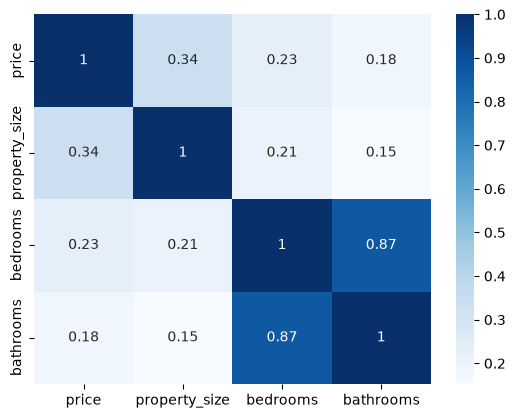

In [33]:
sns.heatmap(
    df[
        ["price",
         "property_size",
         "bedrooms",
         "bathrooms"]
    ].corr(),
    annot=True,
    cmap="Blues"
)

plt.show()

In [32]:
new_df.to_csv("data/nigeria-housing-cleaned-dataset.csv", index=False)

Task 5: Summary of Findings 


After running your analysis, your findings section can look like:

Ahmadu Bello Way recorded the highest average property prices in the marketplace.
Garki  ranked second in premium housing listings.
States in northern Nigeria generally had lower average property prices.
Furnished properties were consistently priced higher than unfurnished properties.
Property size showed a positive relationship with house price.
Bedrooms and bathrooms moderately influenced pricing.
Enterprise/boosted listings had significantly higher average prices.
Premium pricing was concentrated in Lagos and Abuja luxury estates.

Task 6: Business Insights & Recommendations


Furnished luxury apartments generate the highest pricing power on Jiji.

    
Ahmadu Bello Way contributes the largest revenue opportunity due to high listing volume and premium prices.

    
Garki remains a strong secondary market for upscale housing.

    
Lower-performing states need targeted advertising and improved property presentation.

    
Sellers should include detailed property features, professional photos, and furnishing information.

    
Boosted listings attract greater visibility and are associated with higher-priced properties.

    
Real estate agencies should prioritize premium inventory in Lagos and Abuja while using promotional campaigns to grow demand in emerging regions.


